In [1]:
# Import necessary libraries for data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import random
from PIL import Image

# Import deep learning libraries from TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Import evaluation metrics from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Load the dataset annotations 
# along with the image folders (Train, Test, Meta).

try:
    base_path = 'D:/Traffic_Sign_Recognition/'
    # Load the training data
    train_df = pd.read_csv(os.path.join(base_path, 'Train.csv'))

    # Construct the full path for each image in the training set
    train_df['Path'] = train_df['Path'].apply(lambda x: os.path.join(base_path, x))

    # Display the first few rows to verify paths
    print("Updated Train DataFrame head:")
    print(train_df.head())
    
    # Load the test data
    test_df = pd.read_csv(os.path.join(base_path, 'Test.csv'))
    
    # Construct the full path for each image in the test set
    test_df['Path'] = test_df['Path'].apply(lambda x: os.path.join(base_path, x))
    
    # Display the first few rows to verify paths
    print("\nUpdated Test DataFrame head:")
    print(test_df.head())
    
    print("Train.csv loaded successfully. Shape:", train_df.shape)
    print("Test.csv loaded successfully. Shape:", test_df.shape)
    
    # Display the first few rows to verify the structure
    print("\n--- Training Data Head ---")
    print(train_df.head())
    
    print("\n--- Test Data Head ---")
    print(test_df.head())

except FileNotFoundError:
    print("Error: Ensure Train.csv, Test.csv, and Meta.csv are in the same directory as the notebook.")
    train_df, test_df = None, None

C:\Users\prem\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\prem\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\prem\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Updated Train DataFrame head:
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                                                Path  
0  D:/Traffic_Sign_Recognition/Train/20/00020_000...  
1  D:/Traffic_Sign_Recognition/Train/20/00020_000...  
2  D:/Traffic_Sign_Recognition/Train/20/00020_000...  
3  D:/Traffic_Sign_Recognition/Train/20/00020_000...  
4  D:/Traffic_Sign_Recognition/Train/20/00020_000...  

Updated Test DataFrame head:
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     53      54       6       5      48      49       16   
1     42      45       5       5      36      40        1   
2     48      52       6       6      43      47       38   

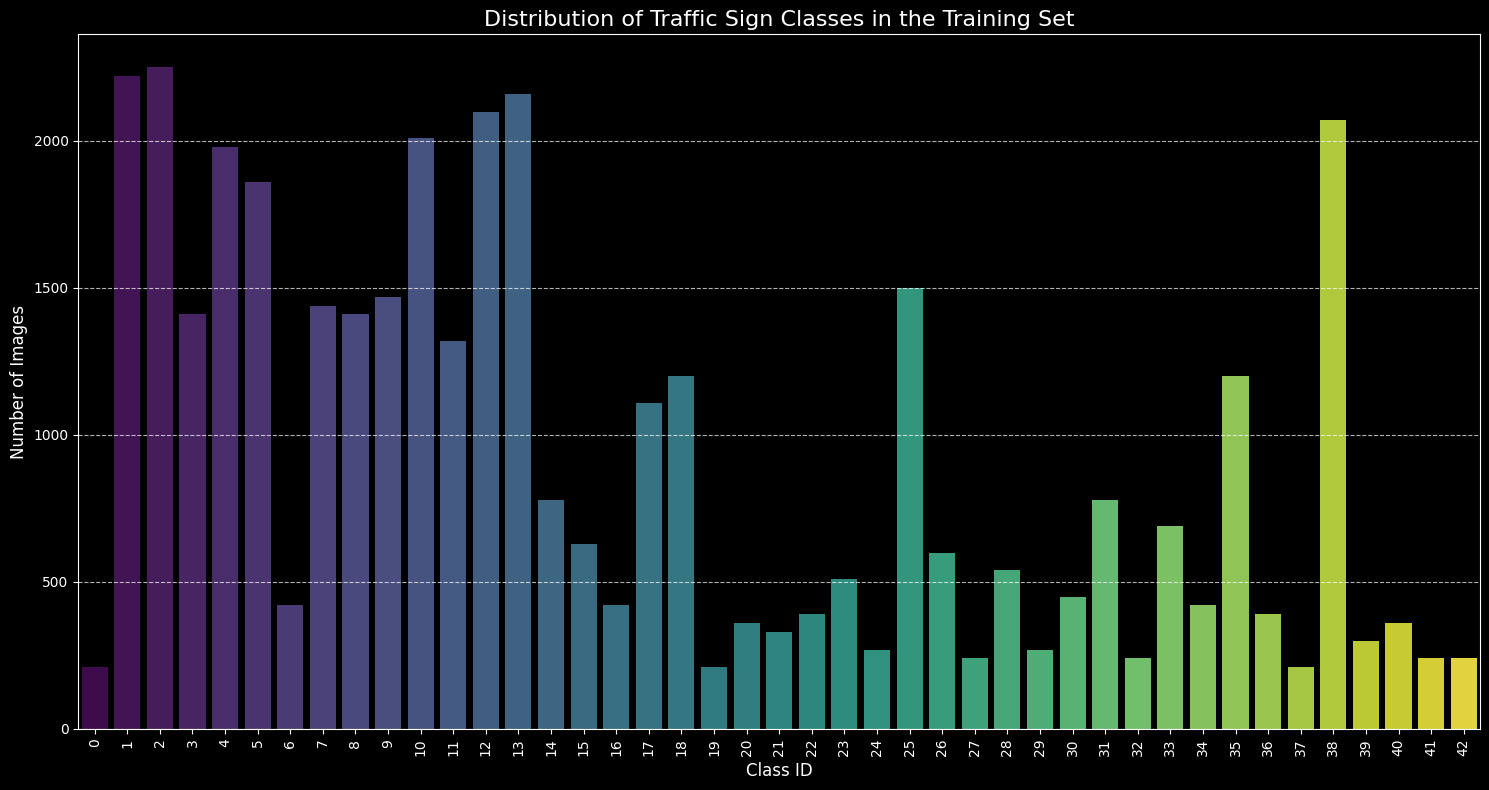

Total number of unique classes: 43


In [2]:
# Analyze and Visualize Class Distribution 
if train_df is not None:
    plt.style.use('dark_background')
    plt.figure(figsize=(15, 8))
    
    class_counts = train_df['ClassId'].value_counts().sort_index()
    
    sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis', hue=class_counts.index, legend=False)
    plt.title('Distribution of Traffic Sign Classes in the Training Set', fontsize=16)
    plt.xlabel('Class ID', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.xticks(rotation=90)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    num_classes = train_df['ClassId'].nunique()
    print(f"Total number of unique classes: {num_classes}")
else:
    print("Training DataFrame not loaded. Cannot perform class distribution analysis.")

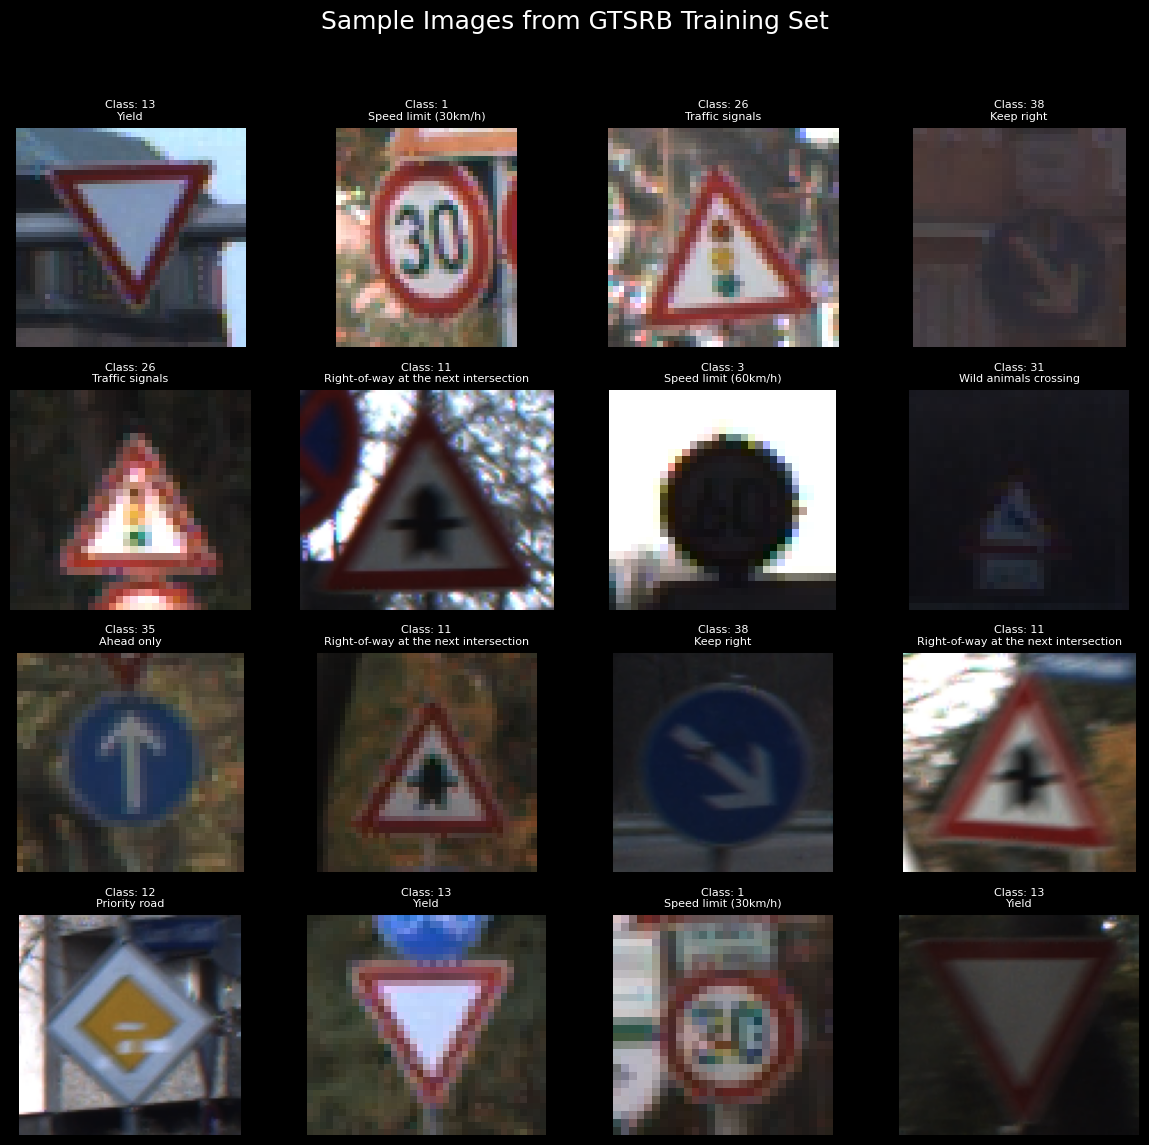

In [3]:
# Define Class Names and Visualize Sample Images 

# Create a dictionary to map ClassId to SignName for easy lookup
class_names = {
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)', 3: 'Speed limit (60km/h)',
    4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)', 6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)',
    8: 'Speed limit (120km/h)', 9: 'No passing', 10: 'No passing for vehicles over 3.5 tons',
    11: 'Right-of-way at the next intersection', 12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles',
    16: 'Vehicles over 3.5 tons prohibited', 17: 'No entry', 18: 'General caution', 19: 'Dangerous curve to the left',
    20: 'Dangerous curve to the right', 21: 'Double curve', 22: 'Bumpy road', 23: 'Slippery road',
    24: 'Road narrows on the right', 25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians',
    28: 'Children crossing', 29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing',
    32: 'End of all speed and passing limits', 33: 'Turn right ahead', 34: 'Turn left ahead', 35: 'Ahead only',
    36: 'Go straight or right', 37: 'Go straight or left', 38: 'Keep right', 39: 'Keep left',
    40: 'Roundabout mandatory', 41: 'End of no passing', 42: 'End of no passing by vehicles over 3.5 tons'
}

if train_df is not None:
    # Display a grid of random images from the training set to show variability
    plt.figure(figsize=(12, 12))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        # Select a random image
        idx = random.randint(0, len(train_df) - 1)
        image_path = train_df.loc[idx, 'Path']
        class_id = train_df.loc[idx, 'ClassId']
        
        # Load image using Pillow (handles various formats gracefully)
        img = Image.open(image_path)
        
        plt.imshow(img)
        plt.title(f'Class: {class_id}\n{class_names[class_id]}', fontsize=8)
        plt.axis('off')
    
    plt.suptitle('Sample Images from GTSRB Training Set', fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [4]:
# --- Load Data and Apply ROI Cropping ---
IMG_SIZE = 48  

def load_and_crop_data(df):
    """Loads images from paths in a DataFrame, crops them using ROI, and resizes."""
    images = []
    labels = []
    
    for index, row in df.iterrows():
        try:
            # Construct the full path
            image_path = row['Path']
            
            # Read the image using OpenCV
            img = cv2.imread(image_path)
            
            # Crop the image using the Region of Interest (ROI) coordinates
            x1, y1 = int(row['Roi.X1']), int(row['Roi.Y1'])
            x2, y2 = int(row['Roi.X2']), int(row['Roi.Y2'])
            img_cropped = img[y1:y2, x1:x2]
            
            # Resize the cropped image to the standard size
            img_resized = cv2.resize(img_cropped, (IMG_SIZE, IMG_SIZE))
            img_normalized = img_resized / 255.0
            
            images.append(img_resized)
            labels.append(row['ClassId'])
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            
    return np.array(images), np.array(labels)

if train_df is not None and test_df is not None:
    # Load training data
    X_data, y_data = load_and_crop_data(train_df)
    
    # Load test data (using the provided Test.csv for evaluation)
    X_test, y_test = load_and_crop_data(test_df)

    print(f"Training data shape: {X_data.shape}")
    print(f"Training labels shape: {y_data.shape}")
    print(f"Test data shape: {X_test.shape}")
    print(f"Test labels shape: {y_test.shape}")
    
    # Split the training data into training and validation sets 
    X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42, stratify=y_data)
    
    print("\n--- After Splitting ---")
    print(f"X_train shape: {X_train.shape}")
    print(f"X_val shape: {X_val.shape}")
    
    # One-Hot Encode the labels
    # This is necessary for categorical crossentropy loss function
    y_train_cat = to_categorical(y_train, num_classes=num_classes)
    y_val_cat = to_categorical(y_val, num_classes=num_classes)
    y_test_cat = to_categorical(y_test, num_classes=num_classes)

else:
    print("DataFrames not loaded. Skipping data loading and splitting.")

Training data shape: (39209, 48, 48, 3)
Training labels shape: (39209,)
Test data shape: (12630, 48, 48, 3)
Test labels shape: (12630,)

--- After Splitting ---
X_train shape: (31367, 48, 48, 3)
X_val shape: (7842, 48, 48, 3)


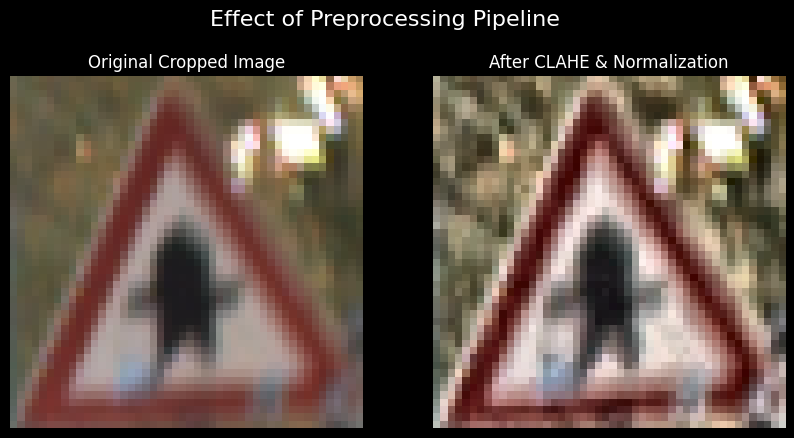

In [5]:
# Advanced Image Preprocessing Function 
def preprocess_image(image):
    """Applies CLAHE for contrast enhancement and normalization."""
    # Convert image to LAB color space
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    
    # Split the LAB image to L, A and B channels
    l, a, b = cv2.split(lab)
    
    # Apply CLAHE to the L-channel
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    
    # Merge the CLAHE enhanced L-channel with the A and B channel
    limg = cv2.merge((cl, a, b))
    
    # Convert image back to BGR color space
    final_image = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    
    # Normalize pixel values to the range 
    final_image = final_image / 255.0
    
    return final_image

# Apply preprocessing to all datasets
if 'X_train' in locals():
    X_train_processed = np.array([preprocess_image(img) for img in X_train])
    X_val_processed = np.array([preprocess_image(img) for img in X_val])
    X_test_processed = np.array([preprocess_image(img) for img in X_test])

    # --- Visualize the effect of preprocessing ---
    plt.figure(figsize=(10, 5))
    random_idx = random.randint(0, len(X_train) - 1)

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(X_train[random_idx], cv2.COLOR_BGR2RGB))
    plt.title('Original Cropped Image')
    plt.axis('off')

    # Processed Image
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor((X_train_processed[random_idx] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
    plt.title('After CLAHE & Normalization')
    plt.axis('off')

    plt.suptitle('Effect of Preprocessing Pipeline', fontsize=16)
    plt.show()
else:
    print("Training data not available for preprocessing visualization.")

In [6]:
# --- Configure Data Augmentation ---
# Using ImageDataGenerator to apply on-the-fly transformations
datagen = ImageDataGenerator(
    rotation_range=10,      # Randomly rotate images by up to 10 degrees
    zoom_range=0.15,        # Randomly zoom in on images by up to 15%
    width_shift_range=0.1,  # Randomly shift images horizontally by up to 10%
    height_shift_range=0.1, # Randomly shift images vertically by up to 10%
    shear_range=0.15,       # Apply shear transformations
    fill_mode='nearest',    # Fill in new pixels with the nearest available pixel
    horizontal_flip=False,  # Disable horizontal flipping to preserve sign meaning
    vertical_flip=False     # Disable vertical flipping
)

# Fit the generator on the training data
if 'X_train_processed' in locals():
    datagen.fit(X_train_processed)
    print("ImageDataGenerator configured and fitted to the training data.")
else:
    print("Processed training data not available for ImageDataGenerator.")

ImageDataGenerator configured and fitted to the training data.


In [7]:
# --- Build the CNN Model Architecture ---
def create_model(num_classes):
    model = Sequential()
    
    # --- Convolutional Block 1 ---
    # Input shape is (IMG_SIZE, IMG_SIZE, 3)
    model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Dropout(rate=0.25))
    
    # --- Convolutional Block 2 ---
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Dropout(rate=0.25))
    
    # --- Classification Head ---
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(rate=0.5))
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

if 'num_classes' in locals():
    model = create_model(num_classes)
    model.summary()
else:
    print("Number of classes not defined. Cannot create model.")

C:\Users\prem\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 46, 46, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 46, 46, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 44, 44, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 44, 44, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 22, 22, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 22, 22, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 20, 20, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 20, 20, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 18, 18, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 18, 18, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 9, 9, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 9, 9, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5184)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       2,654,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │          22,059 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,743,115 (10.46 MB)

 Trainable params: 2,742,731 (10.46 MB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
# --- Compile the Model ---
if 'model' in locals():
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    print("Model compiled successfully.")
else:
    print("Model not created. Skipping compilation.")

Model compiled successfully.


In [9]:
# --- Configure Callbacks and Train the Model ---
if 'X_train_processed' in locals():
    # Define callbacks
    checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001, verbose=1)
    early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)

    # Train the model using the data generator for augmentation
    epochs = 50
    batch_size = 64

    history = model.fit(
        datagen.flow(X_train_processed, y_train_cat, batch_size=batch_size),
        epochs=epochs,
        validation_data=(X_val_processed, y_val_cat),
        callbacks=[checkpoint, reduce_lr, early_stop],
        verbose=1
    )
else:
    print("Processed training data not available. Skipping model training.")

C:\Users\prem\anaconda3\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.5048 - loss: 2.0901
Epoch 1: val_accuracy improved from -inf to 0.90997, saving model to best_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 136s 271ms/step - accuracy: 0.5051 - loss: 2.0883 - val_accuracy: 0.9100 - val_loss: 0.2858 - learning_rate: 0.0010
Epoch 2/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.8592 - loss: 0.4551
Epoch 2: val_accuracy improved from 0.90997 to 0.98891, saving model to best_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 127s 258ms/step - accuracy: 0.8592 - loss: 0.4550 - val_accuracy: 0.9889 - val_loss: 0.0360 - learning_rate: 0.0010
Epoch 3/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.9150 - loss: 0.2781
Epoch 3: val_accuracy did not improve from 0.98891
491/491 ━━━━━━━━━━━━━━━━━━━━ 131s 267ms/step - accuracy: 0.9150 - loss: 0.2781 - val_accuracy: 0.9828 - val_loss: 0.0511 - learning_rate: 0.0010
Epoch 4/50
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.9347 - 

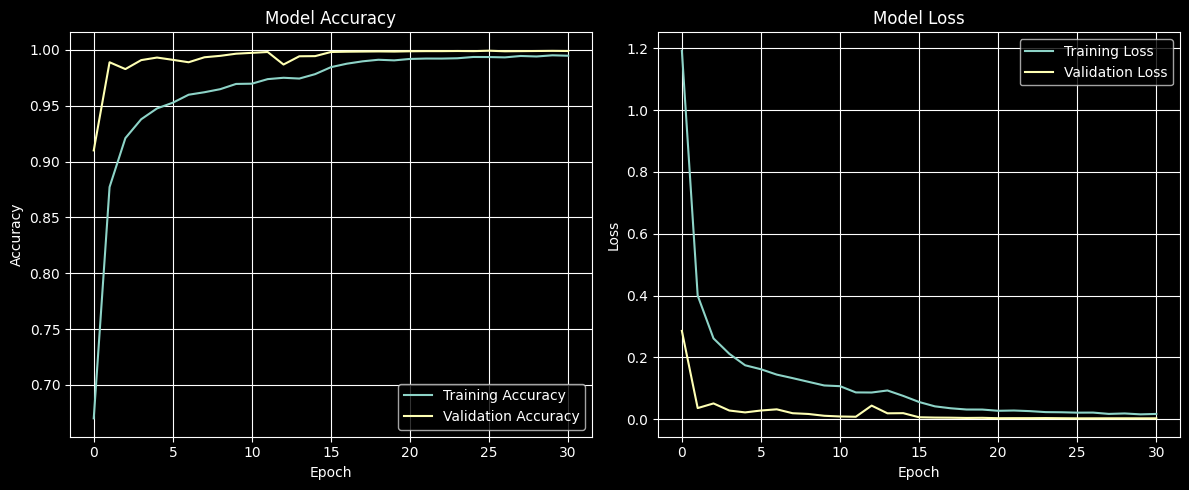

In [10]:
# Plot Training History 
if 'history' in locals():
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Training history not available. Cannot plot.")

Test Accuracy: 98.56%
Test Loss: 0.0716
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step

--- Classification Report ---
                                             precision    recall  f1-score   support

                       Speed limit (20km/h)       1.00      1.00      1.00        60
                       Speed limit (30km/h)       0.99      1.00      0.99       720
                       Speed limit (50km/h)       0.99      0.99      0.99       750
                       Speed limit (60km/h)       1.00      0.97      0.98       450
                       Speed limit (70km/h)       1.00      1.00      1.00       660
                       Speed limit (80km/h)       0.95      0.99      0.97       630
                End of speed limit (80km/h)       1.00      0.89      0.94       150
                      Speed limit (100km/h)       0.98      1.00      0.99       450
                      Speed limit (120km/h)       0.99      0.95      0.97       450
                                 No 

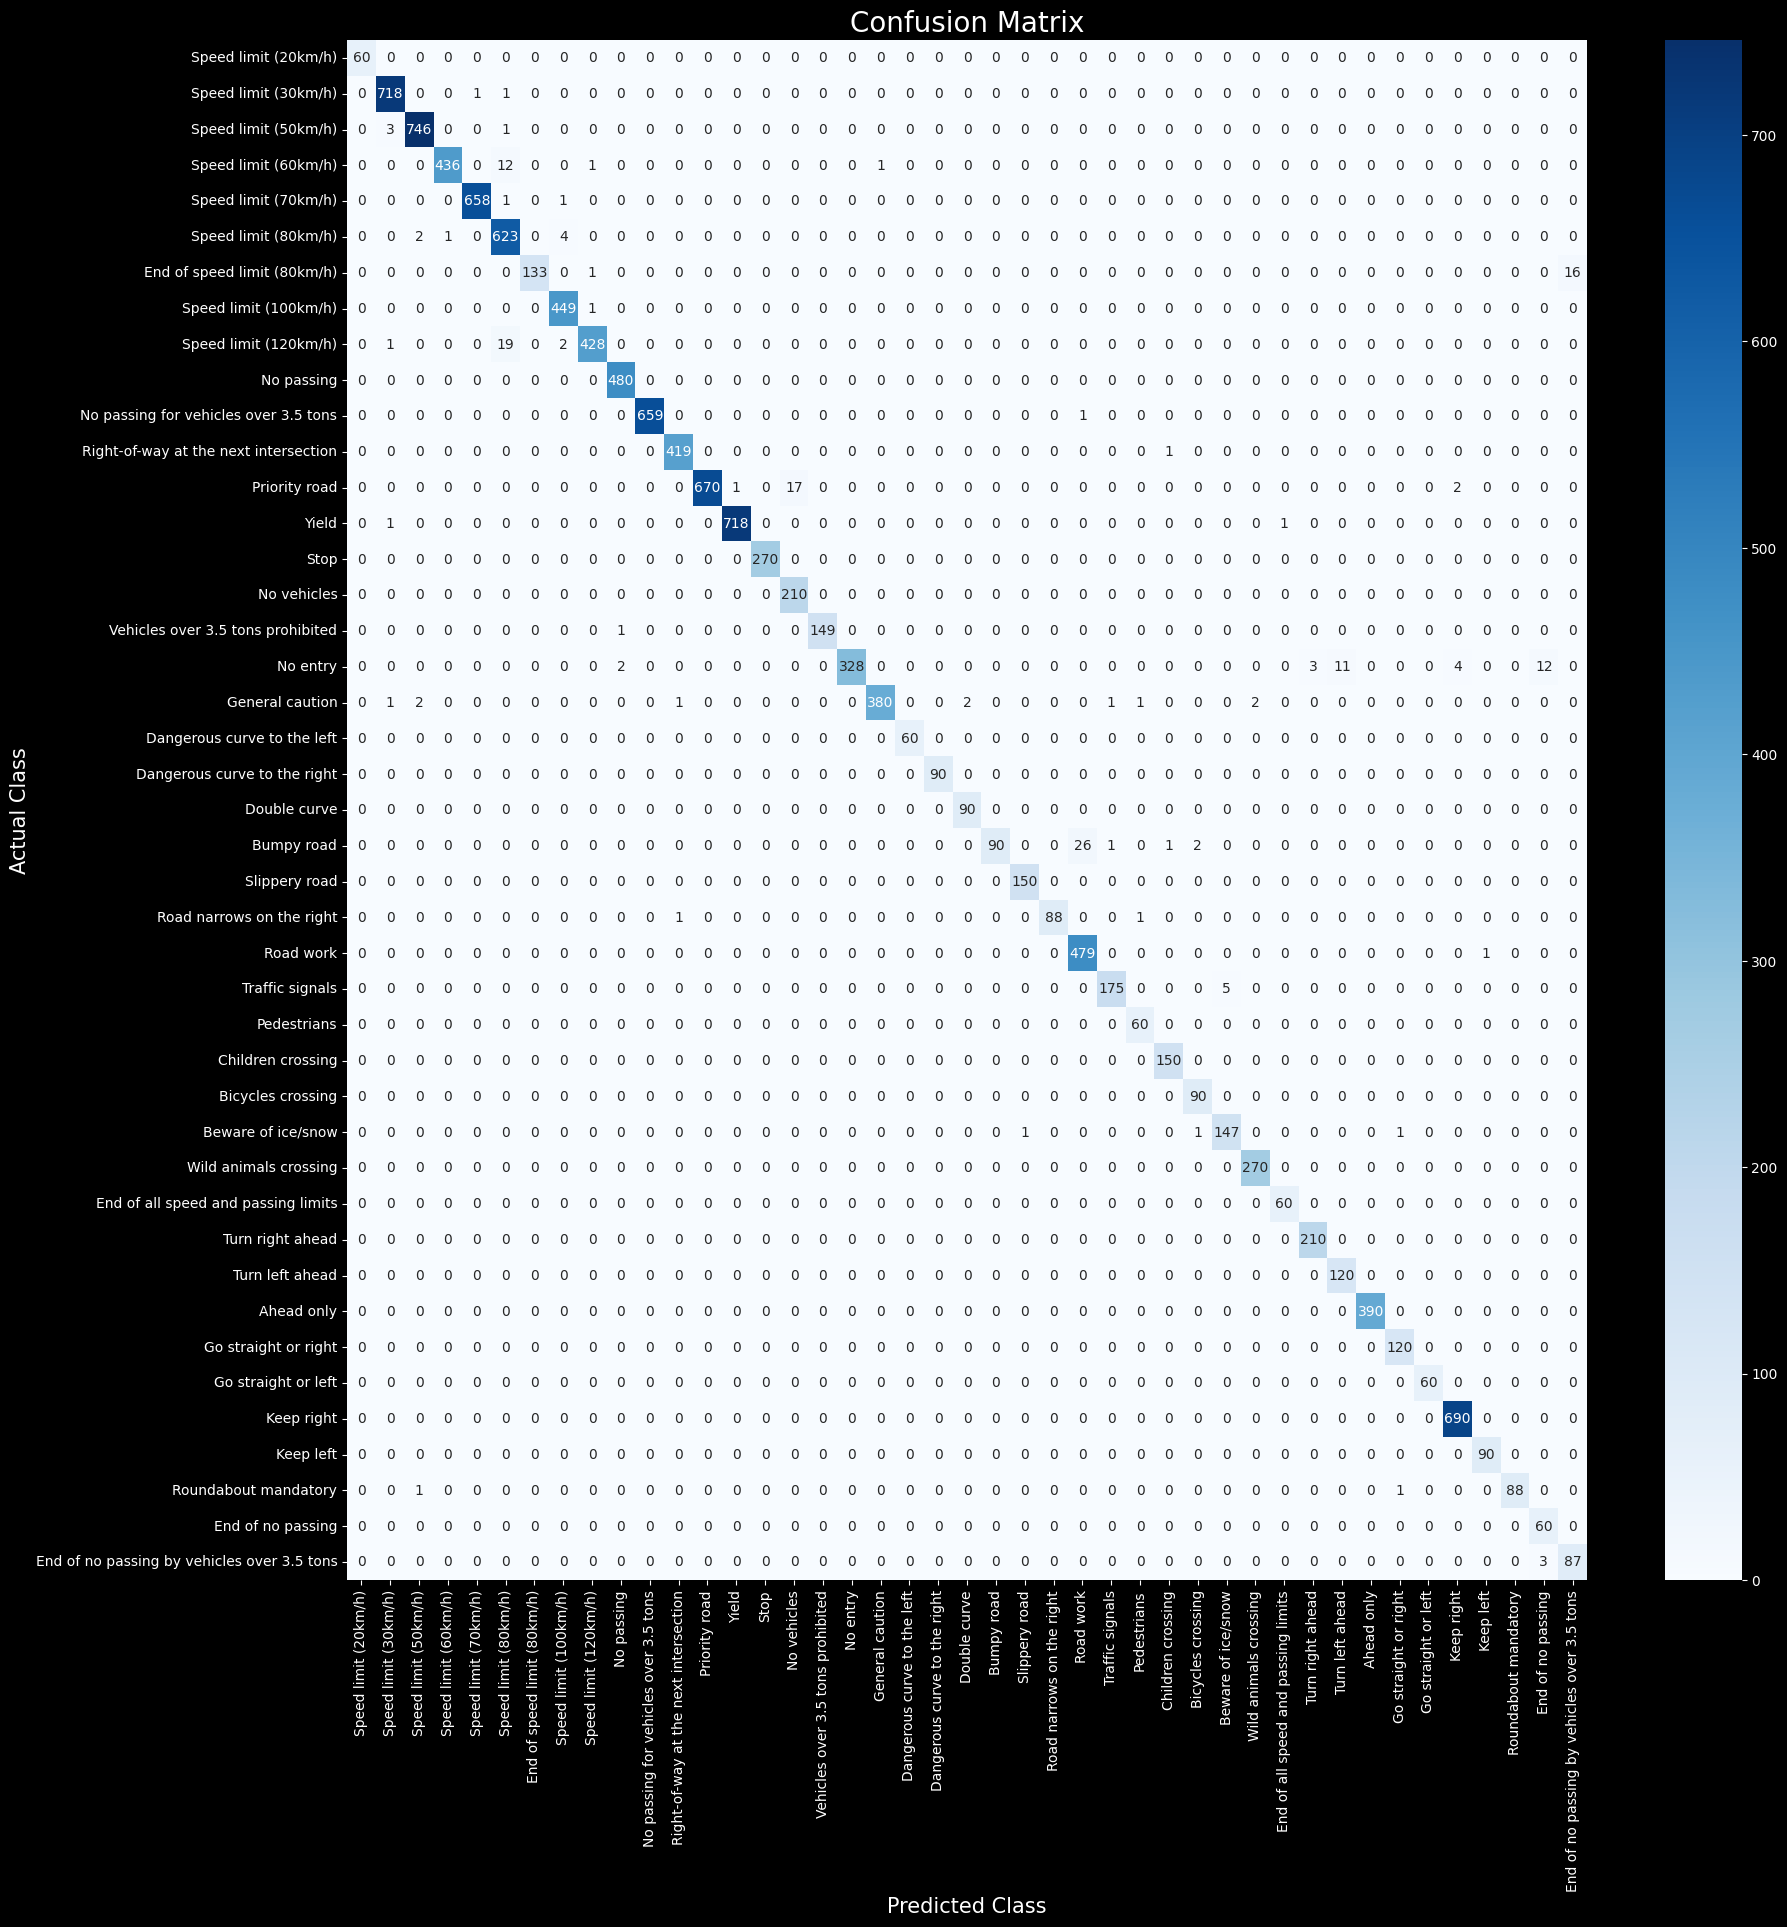

In [11]:
# --- Evaluate the Model on the Test Set ---
if 'model' in locals() and 'X_test_processed' in locals():
    # Load the best model saved by the ModelCheckpoint callback
    best_model = tf.keras.models.load_model('best_model.keras')
    
    # Evaluate the model
    loss, accuracy = best_model.evaluate(X_test_processed, y_test_cat, verbose=0)
    print(f'Test Accuracy: {accuracy * 100:.2f}%')
    print(f'Test Loss: {loss:.4f}')
    
    #Generate Predictions and Classification Report 
    y_pred_probs = best_model.predict(X_test_processed)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    
    # Generate the classification report
    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred_classes, target_names=[class_names[i] for i in range(num_classes)]))

    # Visualize the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(20, 20))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names.values(), yticklabels=class_names.values())
    plt.title('Confusion Matrix', fontsize=20)
    plt.ylabel('Actual Class', fontsize=15)
    plt.xlabel('Predicted Class', fontsize=15)
    plt.show()
else:
    print("Model or test data not available for final evaluation.")

In [16]:
# Create a Prediction Function for Real-Time Use
if 'best_model' in locals():
    def predict_sign(image_frame, model):
        """
        Takes a single image frame (from OpenCV), preprocesses it,
        and returns the predicted class name and confidence.
        """
        # The input frame is assumed to be in BGR format from cv2.
        
        # Preprocessing pipeline
        # Note: For a real-time system, the sign would first be DETECTED.
        # Here, we assume the input frame is already cropped to the sign.
        # If not, the function would need ROI coordinates.
        
        img_resized = cv2.resize(image_frame, (IMG_SIZE, IMG_SIZE))
        img_processed = preprocess_image(img_resized)
        
        # Reshape for model input (add batch dimension)
        img_input = np.expand_dims(img_processed, axis=0)
        
        # Make prediction
        prediction_probs = model.predict(img_input)
        predicted_class_id = np.argmax(prediction_probs)
        prediction_confidence = np.max(prediction_probs)
        
        # Get the class name
        predicted_class_name = class_names[predicted_class_id]
        
        return predicted_class_name, prediction_confidence

    print("Prediction function 'predict_sign' is ready.")
else:
    print("Trained model not available. Cannot create prediction function.")

Prediction function 'predict_sign' is ready.


# For Random Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step


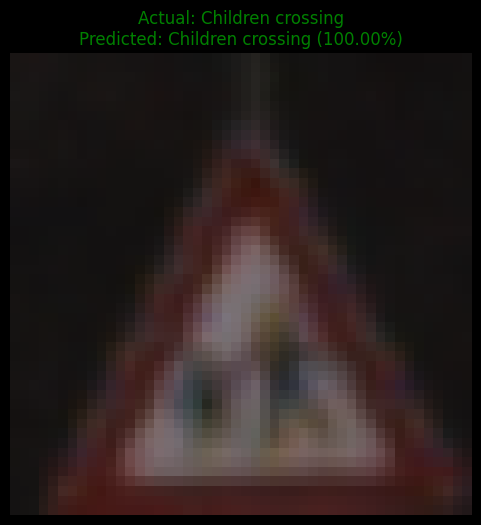

In [20]:
# Load a sample test image 
if 'X_test' in locals() and 'best_model' in locals():
    sample_frame_index = random.randint(0, len(X_test) - 1)
    sample_frame = X_test[sample_frame_index]
    actual_label_id = y_test[sample_frame_index]
    actual_label_name = class_names[actual_label_id]

    # Use the prediction function
    predicted_name, confidence = predict_sign(sample_frame, best_model)

    # Display the result
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB))
    
    title_text = f"Actual: {actual_label_name}\n"
    title_text += f"Predicted: {predicted_name} ({confidence*100:.2f}%)"
    
    # Set title color based on correctness
    title_color = 'green' if actual_label_name == predicted_name else 'red'
    
    plt.title(title_text, color=title_color)
    plt.axis('off')
    plt.show()
else:
    print("Cannot run real-time inference demonstration.")

## For GUI

In [14]:
from PIL import Image, ImageTk
import tkinter as tk
from tkinter import filedialog

In [21]:
# --- GUI Application for Image Upload and Prediction ---
if best_model:
    class TrafficSignApp:
        def __init__(self, root):
            self.root = root
            self.root.title("Traffic Sign Recognizer")
            self.root.geometry("1000x800")
            self.root.configure(bg="#2c3e50")
            
            self.style = {
                "frame_bg": "#34495e",
                "text_fg": "white",
                "header_font": ("Helvetica", 24, "bold"),
                "label_font": ("Helvetica", 16),
                "button_font": ("Helvetica", 12, "bold"),
                "button_bg": "#16a085",
                "button_fg": "white",
                "result_font": ("Helvetica", 18, "bold"),
                "info_font": ("Helvetica", 12, "italic")
            }

            self.image_path = None
            self.create_widgets()

        def create_widgets(self):
            # Main container frame
            main_frame = tk.Frame(self.root, bg=self.root["bg"], padx=20, pady=20)
            main_frame.pack(expand=True, fill=tk.BOTH)

            # Header
            header_label = tk.Label(main_frame, text="Traffic Sign Recognition",
                                    bg=self.root["bg"], fg=self.style["text_fg"], font=self.style["header_font"])
            header_label.pack(pady=(0, 20))

            # Image and Results Frame
            content_frame = tk.Frame(main_frame, bg=self.root["bg"])
            content_frame.pack(expand=True, fill=tk.BOTH, pady=10)

            # Left side: Image Display
            image_container = tk.Frame(content_frame, bg=self.style["frame_bg"], width=500, height=500, highlightbackground="#ecf0f1", highlightthickness=2)
            image_container.pack(side=tk.LEFT, expand=True, fill=tk.BOTH, padx=10)
            image_container.pack_propagate(False)

            self.image_label = tk.Label(image_container, bg=self.style["frame_bg"])
            self.image_label.pack(expand=True, fill=tk.BOTH)
            
            # Right side: Control and Results
            info_container = tk.Frame(content_frame, bg=self.style["frame_bg"], width=400, padx=20, pady=20)
            info_container.pack(side=tk.RIGHT, expand=True, fill=tk.BOTH, padx=10)

            # Control buttons
            control_frame = tk.Frame(info_container, bg=self.style["frame_bg"])
            control_frame.pack(pady=(0, 20))

            button_options = {
                'bg': self.style['button_bg'],
                'fg': self.style['button_fg'],
                'font': self.style['button_font'],
                'relief': tk.FLAT,
                'width': 18
            }

            select_button = tk.Button(control_frame, text="Select & Upload Image", command=self.select_image, **button_options)
            select_button.pack(pady=5)
            
            predict_button = tk.Button(control_frame, text="Predict Uploaded Sign", command=self.predict_uploaded_image, **button_options)
            predict_button.pack(pady=5)

            demo_button = tk.Button(control_frame, text="Predict a Random Sample", command=self.predict_sample, **button_options)
            demo_button.pack(pady=5)

            # Result labels
            info_label = tk.Label(info_container, text="Prediction Results:",
                                  bg=self.style["frame_bg"], fg=self.style["text_fg"], font=self.style["label_font"])
            info_label.pack(pady=(10, 5))

            self.prediction_label = tk.Label(info_container, text="---",
                                             bg=self.style["frame_bg"], fg="#1abc9c", font=self.style["result_font"])
            self.prediction_label.pack()

            self.confidence_label = tk.Label(info_container, text="Confidence: ---",
                                              bg=self.style["frame_bg"], fg=self.style["text_fg"], font=self.style["label_font"])
            self.confidence_label.pack()

            self.status_label = tk.Label(info_container, text="Waiting for an image...",
                                         bg=self.style["frame_bg"], fg="#ecf0f1", font=self.style["info_font"])
            self.status_label.pack(pady=(10, 0))


        def select_image(self):
            self.image_path = filedialog.askopenfilename(
                initialdir=os.getcwd(),
                title="Select a Traffic Sign Image",
                filetypes=(
                    ("Image files", "*.png;*.jpg;*.jpeg;*.bmp"),
                    ("All files", "*.*")
                )
            )
            if self.image_path:
                self.display_image(self.image_path)
                self.prediction_label.config(text="---")
                self.confidence_label.config(text="Confidence: ---")
                self.status_label.config(text="Image loaded. Click 'Predict Uploaded Sign'.", fg="white")

        def display_image(self, path):
            img = Image.open(path)
            width, height = img.size
            
            target_size = 480
            if width > height:
                new_width = target_size
                new_height = int(height * (new_width / width))
            else:
                new_height = target_size
                new_width = int(width * (new_height / height))

            img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
            photo = ImageTk.PhotoImage(img)
            self.image_label.config(image=photo)
            self.image_label.image = photo
            self.image_label.pack(expand=True)

        def display_image_from_cv2(self, cv2_img):
            img_rgb = cv2.cvtColor(cv2_img, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(img_rgb)
            
            target_size = 480
            width, height = pil_img.size
            if width > height:
                new_width = target_size
                new_height = int(height * (new_width / width))
            else:
                new_height = target_size
                new_width = int(width * (new_height / height))

            pil_img = pil_img.resize((new_width, new_height), Image.Resampling.LANCZOS)
            photo = ImageTk.PhotoImage(pil_img)
            self.image_label.config(image=photo)
            self.image_label.image = photo
            self.image_label.pack(expand=True)

        def predict_uploaded_image(self):
            if self.image_path:
                try:
                    img = cv2.imread(self.image_path)
                    if img is None:
                        self.status_label.config(text="Error: Could not read image file.", fg="red")
                        return

                    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    img_processed = preprocess_image(img_resized)
                    img_input = np.expand_dims(img_processed, axis=0)
                    
                    prediction_probs = best_model.predict(img_input, verbose=0)
                    predicted_class_id = np.argmax(prediction_probs)
                    confidence = np.max(prediction_probs)
                    
                    predicted_class_name = class_names[predicted_class_id]
                    result_text = f"Prediction on your image:\n{predicted_class_name} ({confidence * 100:.2f}%)"
                    self.prediction_label.config(text=predicted_class_name)
                    self.confidence_label.config(text=f"Confidence: {confidence * 100:.2f}%")
                    self.status_label.config(text="Prediction complete for uploaded image.", fg="white")

                except Exception as e:
                    self.status_label.config(text=f"An error occurred during prediction: {e}", fg="red")
            else:
                self.status_label.config(text="Please select an image first!", fg="orange")
        
        def predict_sample(self):
            if 'test_df' in globals():
                try:
                    sample_df_row = test_df.sample(1).iloc[0]
                    image_path = sample_df_row['Path']
                    actual_label_name = class_names[sample_df_row['ClassId']]

                    img = cv2.imread(image_path)
                    if img is None:
                        self.status_label.config(text="Error: Could not read sample image file.", fg="red")
                        return

                    x1, y1 = int(sample_df_row['Roi.X1']), int(sample_df_row['Roi.Y1'])
                    x2, y2 = int(sample_df_row['Roi.X2']), int(sample_df_row['Roi.Y2'])
                    img_cropped = img[y1:y2, x1:x2]

                    self.display_image_from_cv2(img_cropped)

                    predicted_name, confidence = predict_sign(img_cropped, best_model)
                    
                    self.prediction_label.config(text=predicted_name)
                    self.confidence_label.config(text=f"Confidence: {confidence * 100:.2f}%")
                    
                    if predicted_name == actual_label_name:
                        self.status_label.config(text=f"Prediction is correct! (Actual: {actual_label_name})", fg="#00ff00")
                    else:
                        self.status_label.config(text=f"Prediction is incorrect. (Actual: {actual_label_name})", fg="red")

                except Exception as e:
                    self.status_label.config(text=f"An error occurred with the sample prediction: {e}", fg="red")
            else:
                self.status_label.config(text="Test data not available. Cannot predict sample.", fg="orange")

    root = tk.Tk()
    app = TrafficSignApp(root)
    root.mainloop()
else:
    print("GUI cannot be started because the model failed to load.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
